# ZenteiQ MaxText Assignment — GPU (T4) Backend
> **Runtime:** T4 GPU &nbsp;|&nbsp; **MaxText v0.2.2** &nbsp;|&nbsp; **Dataset:** Synthetic

⚠️ **Before running:** `Runtime → Change runtime type → Hardware accelerator → T4 GPU`

**Cells must be run in order.**

### Bugs fixed in this version
| # | Bug | Fix |
|---|---|---|
| 1 | `pip --resolution=lowest` unsupported flag | Use `uv pip install` |
| 2 | Missing `DECOUPLE_GCLOUD=TRUE` → GCS errors | Set env var + pass to subprocess |
| 3 | `override_model_config` absent → CLI override blocked | Added to all scaled runs |
| 4 | `qwen3-1.7b` doesn't exist in v0.2.2 | Direct manual scaling from 0.6B base |
| 5 | `subprocess.run` buffers output → frozen notebook | Replaced with `Popen` + streaming |
| 6 | MLA params not overridden → shape mismatch | `q_lora_rank`, `kv_lora_rank` etc. added |
| 7 | `maxtext.__version__` AttributeError | Wrapped in `getattr` |
| 8 | Brittle single-regex metric parser | Per-field extraction with fallback patterns |

## Phase 0 — Installation
*Run once per session. If prompted to restart, do so before continuing.*

In [ ]:
!pip install -q uv
!uv pip install "maxtext[cuda12]==0.2.1" --resolution=lowest --system -q
print('✅  Installation complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.4/25.4 MB 39.7 MB/s eta 0:00:00
✅  Installation complete.


## Phase 0 — Backend Verification

In [ ]:
import jax
assert jax.default_backend() == 'gpu', f"Expected gpu, got {jax.default_backend()}. Switch runtime!"
print(f'✅  GPU confirmed  |  devices={jax.devices()}')
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader

✅  GPU confirmed  |  devices=[CudaDevice(id=0)]
Tesla T4, 15360 MiB, 580.82.07


## Phase 0 — Environment, Utilities & DECOUPLE_GCLOUD

In [ ]:
BACKEND = "gpu"

import os, re, subprocess, time, json, sys

# ─── CRITICAL FIX 1: Bypass GCS dependencies (run locally without a GCS bucket) ───
os.environ["DECOUPLE_GCLOUD"] = "TRUE"
os.environ["LOCAL_BASE_OUTPUT"] = "/content/maxtext_outputs"

# Directories
BASE_OUTPUT_DIR = "/content/maxtext_outputs"
LOG_DIR         = "/content/logs"
for d in [BASE_OUTPUT_DIR, f"{LOG_DIR}/task2", f"{LOG_DIR}/task3"]:
    os.makedirs(d, exist_ok=True)
print(f"✅ Output dir : {BASE_OUTPUT_DIR}")
print(f"✅ Log dir    : {LOG_DIR}")

# ─── MaxText version (graceful — __version__ may not exist) ─────────────────
try:
    import maxtext
    print(f"✅ MaxText    : {getattr(maxtext, '__version__', 'installed (version attr absent)')}")
except Exception as e:
    print(f"⚠️  MaxText import: {e}")

import jax
print(f"✅ JAX version: {jax.__version__}")
print(f"✅ Backend    : {jax.default_backend()}")
print(f"✅ Devices    : {jax.devices()}")

# ─── FIX 2: run_train uses Popen for real-time streaming ────────────────────
def run_train(config_args: dict, log_file: str) -> str:
    """Launch MaxText training; stream stdout live; return full log text."""
    os.makedirs(os.path.dirname(log_file), exist_ok=True)
    cmd = ["python3", "-m", "maxtext.trainers.pre_train.train"]
    for k, v in config_args.items():
        cmd.append(f"{k}={v}")

    # Pass DECOUPLE_GCLOUD into the subprocess environment
    env = os.environ.copy()
    env["DECOUPLE_GCLOUD"] = "TRUE"

    print(f"\n{'='*70}")
    print(f"🚀  CMD : {' '.join(cmd)}")
    print(f"📝  LOG : {log_file}")
    print(f"{'='*70}\n")

    buf = []
    t0  = time.time()
    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, env=env
    )
    for line in iter(proc.stdout.readline, ""):
        print(line, end="", flush=True)
        buf.append(line)
    proc.wait()
    elapsed = time.time() - t0

    full = "".join(buf)
    with open(log_file, "w") as f:
        f.write(full)

    status = "✅" if proc.returncode == 0 else "❌"
    print(f"\n{status}  Exit={proc.returncode}  Wall={elapsed:.1f}s\n")
    return full

# ─── FIX 3: Robust metrics parser (handles varying field order / prefixes) ──
_FIELD_RE = {
    "step"          : re.compile(r"completed step:\s*(\d+)",                re.I),
    "seconds"       : re.compile(r"seconds:\s*([\d.]+)",                    re.I),
    "tflops"        : re.compile(r"TFLOP(?:/s)?/device:\s*([\d.]+)|per_device_tflops[_/\w]*:\s*([\d.]+)", re.I),
    "tokens_per_sec": re.compile(r"Tokens/s/device:\s*([\d.]+)|tokens_per_second:\s*([\d.]+)", re.I),
    "total_weights" : re.compile(r"total_weights:\s*([\d]+)",               re.I),
    "loss"          : re.compile(r"\bloss:\s*([\d.]+)",                     re.I),
    "learning_rate" : re.compile(r"learning_rate:\s*([\d.eE+\-]+)",         re.I),
    "grad_norm"     : re.compile(r"grad_norm:\s*([\d.]+)",                  re.I),
}

def parse_metrics(log_text: str) -> dict:
    metrics   = {}
    all_steps = []
    for line in log_text.splitlines():
        if "completed step" not in line.lower():
            continue
        row = {}
        for key, pat in _FIELD_RE.items():
            m = pat.search(line)
            if m:
                val = next((g for g in m.groups() if g is not None), None)
                if val:
                    try:    row[key] = float(val)
                    except: row[key] = val
        if "step" in row:
            all_steps.append(row)
    metrics["steps"] = all_steps

    # Memory
    mm = re.search(
        r"Total memory size:\s*([\d.]+)\s*GB.*?Output size:\s*([\d.]+)\s*GB"
        r".*?Temp size:\s*([\d.]+)\s*GB.*?Argument size:\s*([\d.]+)\s*GB",
        log_text, re.S)
    if mm:
        metrics["mem_total_gb"]    = float(mm.group(1))
        metrics["mem_output_gb"]   = float(mm.group(2))
        metrics["mem_temp_gb"]     = float(mm.group(3))
        metrics["mem_argument_gb"] = float(mm.group(4))

    # Param count
    pm = re.search(r"(?:number(?:\s+of)?\s+parameters|num_params):\s*([\d.]+)\s*(?:billion)?", log_text, re.I)
    if pm: metrics["params_billion"] = float(pm.group(1))

    # Model TFLOPs / step
    tm = re.search(r"Total TFLOPs:\s*([\d.]+)", log_text)
    if tm: metrics["model_tflops_step"] = float(tm.group(1))

    # Device count
    dm = re.search(r"Num_devices:\s*(\d+)", log_text)
    if dm: metrics["num_devices"] = int(dm.group(1))

    return metrics

def summarize(metrics: dict, label: str) -> dict | None:
    steps = metrics.get("steps", [])
    if not steps:
        print(f"❌  No step data for: {label}")
        return None
    steady = [s for s in steps if s.get("step", 0) > 0] or steps
    n = len(steady)
    avg_s  = sum(s.get("seconds", 0)     for s in steady) / n
    avg_tf = sum(s.get("tflops", 0)      for s in steady) / n
    avg_tk = sum(s.get("tokens_per_sec", 0) for s in steady) / n
    avg_lr = sum(s.get("learning_rate", 0)  for s in steady) / n
    avg_gn = sum(s.get("grad_norm", 0)      for s in steady) / n
    last   = steps[-1]
    jit    = steps[0].get("seconds", 0)
    print(f"\n{'='*64}")
    print(f"  📊  {label}")
    print(f"{'='*64}")
    print(f"  Parameters (B)       : {metrics.get('params_billion','N/A')}")
    print(f"  Num devices          : {metrics.get('num_devices','N/A')}")
    print(f"  Model TFLOPs/step    : {metrics.get('model_tflops_step','N/A')}")
    print(f"  Mem total (GB)       : {metrics.get('mem_total_gb','N/A')}")
    print(f"  {'─'*56}")
    print(f"  JIT warmup step (s)  : {jit:.3f}")
    print(f"  Avg step time (s)    : {avg_s:.4f}")
    print(f"  Avg TFLOP/s/device   : {avg_tf:.4f}")
    print(f"  Avg Tokens/s/device  : {avg_tk:.2f}")
    print(f"  Avg learning rate    : {avg_lr:.6f}")
    print(f"  Avg grad norm        : {avg_gn:.4f}")
    print(f"  Final loss (step {int(last.get('step',0))}): {last.get('loss','N/A')}")
    print(f"{'='*64}")
    return {
        "label": label, "params_b": metrics.get("params_billion"),
        "num_devices": metrics.get("num_devices"),
        "mem_total_gb": metrics.get("mem_total_gb"),
        "model_tflops_step": metrics.get("model_tflops_step"),
        "jit_warmup_s": jit,
        "avg_step_s": avg_s, "avg_tflops": avg_tf,
        "avg_tokens_per_sec": avg_tk,
        "avg_learning_rate": avg_lr, "avg_grad_norm": avg_gn,
        "final_loss": last.get("loss"),
        "total_steps": len(steps),
    }

print("✅  All utilities loaded.")


✅ Output dir : /content/maxtext_outputs
✅ Log dir    : /content/logs
✅ MaxText    : installed (version attr absent)
✅ JAX version: 0.8.1
✅ Backend    : gpu
✅ Devices    : [CudaDevice(id=0)]
✅  All utilities loaded.


---
## Task 1 — Data Format Investigation

In [ ]:
# Task 1 — Explore MaxText source to find all dataset_type options
print("Cloning MaxText source (shallow) for pipeline inspection...")
import subprocess, os
if not os.path.exists("/content/maxtext_src"):
    subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", "maxtext-v0.2.2",
         "https://github.com/AI-Hypercomputer/maxtext.git", "/content/maxtext_src"],
        check=True
    )
print("\n📂 Input pipeline files:")
for f in sorted(os.listdir("/content/maxtext_src/src/maxtext/input_pipeline/")):
    print(f"   {f}")

print("\n📋 dataset_type references in input_pipeline_interface.py:")
result = subprocess.run(
    ["grep", "-n", "dataset_type", "/content/maxtext_src/src/maxtext/input_pipeline/input_pipeline_interface.py"],
    capture_output=True, text=True)
print(result.stdout[:3000])


Cloning MaxText source (shallow) for pipeline inspection...

📂 Input pipeline files:
   __init__.py
   data_processing_utils.py
   distillation_data_processing.py
   grain_data_processing.py
   grain_tokenizer.py
   hf_data_processing.py
   input_pipeline_interface.py
   input_pipeline_utils.py
   instruction_data_processing.py
   multihost_dataloading.py
   olmo_data.py
   olmo_data_grain.py
   olmo_grain_data_processing.py
   packing
   protos
   synthetic_data_processing.py
   tfds_data_processing.py
   tfds_data_processing_c4_mlperf.py
   tokenizer.py

📋 dataset_type references in input_pipeline_interface.py:
70:  if config.dataset_type == "synthetic":
73:  dataset_type_to_train_eval_iterator = {
82:  if config.dataset_type in ["tfds", "grain", "hf", "c4_mlperf", "olmo_grain"]:
83:    if config.dataset_type == "c4_mlperf":
85:    train_iterator, eval_iterator = dataset_type_to_train_eval_iterator[config.dataset_type]
88:        f"WARNING: '{config.dataset_type}' is not a supported 

## Task 1 — MaxText Data Format Summary

MaxText routes data loading via the `dataset_type` config key to one of four pipelines:

| `dataset_type` | Pipeline | File format | Random access | Preemption-safe | Best for |
|---|---|---|---|---|---|
| `synthetic` | Built-in generator | None (random tensors) | ✅ N/A | ✅ | **Hardware benchmarking** — no I/O overhead |
| `grain` | Google Grain | ArrayRecord, TFRecord, Parquet | ArrayRecord ✅ / others ❌ | ✅ | Production pre-training |
| `hf` | HuggingFace Datasets | Parquet, JSON, CSV, Arrow, Hub | ❌ sequential | ❌ | Prototyping / rapid iteration |
| `tfds` | TensorFlow Datasets | TFRecord only | ❌ | ❌ | Legacy TF-based pipelines |

**Why `synthetic` for Tasks 2 & 3:**  
- Zero disk I/O — all sequences are random integer tensors generated on-the-fly at full `max_target_length`  
- Fully deterministic and preemption-safe  
- Removes data-loading from the critical path → pure hardware throughput benchmark  
- Standard practice for cross-backend perf comparisons

**Grain / ArrayRecord** is the recommended production pipeline: globally shuffled, preemption-resilient via deterministic element indices, and supports multi-host parallelism cleanly.


---
## Task 2A — Qwen 0.6B (Baseline) on GPU (T4)
Config: `model_name=qwen3-0.6b`, `steps=50`, `dataset_type=synthetic`, `max_target_length=512`, `per_device_batch_size=2`

In [ ]:
q06b_cfg = {
    "model_name": "qwen3-0.6b",
    "steps": "50",
    "dataset_type": "synthetic",
    "base_output_directory": "/content/maxtext_outputs",
    "run_name": "qwen_0.6b_gpu",
    "enable_checkpointing": "false",
    "max_target_length": "512",
    "per_device_batch_size": "2",
}

log_q06b = run_train(q06b_cfg, f"{LOG_DIR}/task2/qwen_0.6b_gpu.log")
met_qwen06b = parse_metrics(log_q06b)
sum_qwen06b = summarize(met_qwen06b, 'Qwen 0.6B — GPU (T4)')


🚀  CMD : python3 -m maxtext.trainers.pre_train.train model_name=qwen3-0.6b steps=50 dataset_type=synthetic base_output_directory=/content/maxtext_outputs run_name=qwen_0.6b_gpu enable_checkpointing=false max_target_length=512 per_device_batch_size=2
📝  LOG : /content/logs/task2/qwen_0.6b_gpu.log

W0619 23:38:45.433004 137538958226048 pyconfig.py:90] No config file provided, using default config mapping: /usr/local/lib/python3.12/dist-packages/maxtext/configs/base.yml
INFO:2026-06-19 23:38:45,730:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
I0619 23:38:45.730083 137538958226048 xla_bridge.py:812] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
W0619 23:38:45.938663    2910 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extrac

---
## Task 2B — Qwen ~1.7B (Scaled) on GPU (T4)
> `qwen3-1.7b` **does not exist** in MaxText v0.2.2. We manually scale from `qwen3-0.6b` by overriding architecture parameters.

**What changed vs 0.6B:**
- `base_emb_dim`: 1024 → 2048
- `head_dim`: 64 → 128
- `base_mlp_dim`: ~2816 → 5504
- `base_num_decoder_layers`: 28 → 28 (unchanged)
- `base_num_query_heads` / `base_num_kv_heads`: unchanged
- `override_model_config=True` required to allow CLI to override model-YAML keys

In [ ]:
q17b_cfg = {
    "model_name": "qwen3-0.6b",
    "override_model_config": "True",
    "steps": "50",
    "dataset_type": "synthetic",
    "base_output_directory": "/content/maxtext_outputs",
    "run_name": "qwen_1.7b_gpu",
    "enable_checkpointing": "false",
    "max_target_length": "512",
    "per_device_batch_size": "1",
    "base_emb_dim": "2048",
    "head_dim": "128",
    "base_num_query_heads": "16",
    "base_num_kv_heads": "8",
    "base_mlp_dim": "5504",
    "base_num_decoder_layers": "28",
}

log_q17b = run_train(q17b_cfg, f"{LOG_DIR}/task2/qwen_1.7b_gpu.log")
met_qwen17b = parse_metrics(log_q17b)
sum_qwen17b = summarize(met_qwen17b, 'Qwen ~1.7B — GPU (T4)')


🚀  CMD : python3 -m maxtext.trainers.pre_train.train model_name=qwen3-0.6b override_model_config=True steps=50 dataset_type=synthetic base_output_directory=/content/maxtext_outputs run_name=qwen_1.7b_gpu enable_checkpointing=false max_target_length=512 per_device_batch_size=1 base_emb_dim=2048 head_dim=128 base_num_query_heads=16 base_num_kv_heads=8 base_mlp_dim=5504 base_num_decoder_layers=28
📝  LOG : /content/logs/task2/qwen_1.7b_gpu.log

W0619 23:39:31.587181 138791934771840 pyconfig.py:90] No config file provided, using default config mapping: /usr/local/lib/python3.12/dist-packages/maxtext/configs/base.yml
INFO:2026-06-19 23:39:31,855:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
I0619 23:39:31.855242 138791934771840 xla_bridge.py:812] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file 

---
## Task 2 — Dense Model Comparison on GPU (T4)

In [ ]:
# Build the per-backend comparison table
import pandas as pd

summaries = [s for s in [sum_qwen06b, sum_qwen17b, None] if s]
if summaries:
    df = pd.DataFrame(summaries).set_index("label")
    cols = ["params_b","num_devices","avg_step_s","avg_tflops",
            "avg_tokens_per_sec","avg_grad_norm","final_loss","mem_total_gb"]
    df = df[[c for c in cols if c in df.columns]]
    print(f"\n{'='*80}")
    print(f"  BACKEND COMPARISON — ALL MODELS")
    print(f"{'='*80}")
    print(df.to_string())
    df.to_csv(f"{LOG_DIR}/summary_{BACKEND}.csv")
    print(f"\n✅  Saved: {LOG_DIR}/summary_{BACKEND}.csv")


---
## Task 3 — DeepSeek MoE (Sub-1B) on GPU (T4)
**Base:** `deepseek2-16b` (DeepSeek V2 with MLA attention + MoE)

**What we changed to reach sub-1B:**
| Parameter | Original (16B) | Ours (sub-1B) | Why |
|---|---|---|---|
| `base_emb_dim` | 2048 | 768 | Primary size driver |
| `base_num_decoder_layers` | ~27 | 12 | Fewer layers → far fewer params |
| `num_experts` | 64+ | 8 | Total expert count is biggest MoE param |
| `base_moe_mlp_dim` | 1536+ | 768 | Expert FFN width |
| `q_lora_rank` | ~512 | 192 | MLA low-rank query proj (must be < emb_dim) |
| `kv_lora_rank` | ~128 | 48 | MLA low-rank KV proj |
| `qk_nope_head_dim` | 128 | 64 | Non-RoPE head dim |
| `qk_rope_head_dim` | 64 | 32 | RoPE head dim |
| `v_head_dim` | 128 | 64 | Value head dim |

**Active vs total params:** `num_experts_per_tok=2` means only 2 of 8 experts are active per token per MoE layer — the signature MoE efficiency.

In [ ]:
# Parameter count estimator (run before training to confirm sub-1B for DeepSeek)
def estimate_params(
    vocab=102400, emb_dim=768, mlp_dim=1536, moe_mlp_dim=768,
    n_layers=12, first_dense=1, n_experts=8, shared=1, top_k=2,
    n_heads=8, kv_heads=4, head_dim=96,
    q_lora_rank=192, kv_lora_rank=48
):
    """Rough DeepSeek-MLA MoE parameter estimate."""
    moe_layers = n_layers - first_dense
    embed      = vocab * emb_dim                                    # shared in/out
    # MLA attention (per layer): low-rank projs + o_proj
    attn_per   = (q_lora_rank * emb_dim +                          # W_dq
                  q_lora_rank * (n_heads * head_dim) +             # W_uq
                  (kv_lora_rank + n_heads // kv_heads * 32) * emb_dim +  # W_dkv
                  kv_lora_rank * (kv_heads * head_dim * 2) +       # W_uk, W_uv
                  n_heads * head_dim * emb_dim)                     # W_o
    attn_total = attn_per * n_layers
    dense_ffn  = first_dense * 3 * emb_dim * mlp_dim
    expert_ffn = 3 * emb_dim * moe_mlp_dim                         # one expert
    routed     = moe_layers * n_experts * expert_ffn
    shared_ffn = moe_layers * shared * expert_ffn
    total      = embed + attn_total + dense_ffn + routed + shared_ffn
    # Active params per token (embedding counted once, top_k experts active)
    active = embed + attn_total + dense_ffn + moe_layers * (top_k + shared) * expert_ffn
    return total / 1e9, active / 1e9

t, a = estimate_params()
print(f"Estimated TOTAL params  : {t:.3f}B")
print(f"Estimated ACTIVE params : {a:.3f}B  (top-2 routing + 1 shared expert)")
assert t < 1.0, f"Total {t:.3f}B exceeds 1B — reduce dimensions!"
print("✅  Confirmed under 1B total parameters.")


Estimated TOTAL params  : 0.269B
Estimated ACTIVE params : 0.153B  (top-2 routing + 1 shared expert)
✅  Confirmed under 1B total parameters.


In [ ]:
ds_cfg = {
    "model_name": "deepseek2-16b",
    "override_model_config": "True",
    "steps": "50",
    "dataset_type": "synthetic",
    "base_output_directory": "/content/maxtext_outputs",
    "run_name": "deepseek_sub1b_gpu",
    "enable_checkpointing": "false",
    "max_target_length": "512",
    "per_device_batch_size": "1",
    "base_emb_dim": "768",
    "base_num_query_heads": "8",
    "base_num_kv_heads": "8",
    "base_mlp_dim": "1536",
    "base_moe_mlp_dim": "768",
    "base_num_decoder_layers": "12",
    "num_experts": "8",
    "num_experts_per_tok": "2",
    "shared_experts": "1",
    "first_num_dense_layers": "1",
    "interleave_moe_layer_step": "1",
    "q_lora_rank": "192",
    "kv_lora_rank": "48",
    "qk_nope_head_dim": "64",
    "qk_rope_head_dim": "32",
    "v_head_dim": "96",
    "head_dim": "96",
    "capacity_factor": "-1.0",
}

log_ds = run_train(ds_cfg, f"{LOG_DIR}/task3/deepseek_sub1b_gpu.log")
met_deepseek = parse_metrics(log_ds)
sum_deepseek = summarize(met_deepseek, 'DeepSeek MoE <1B — GPU (T4)')


🚀  CMD : python3 -m maxtext.trainers.pre_train.train model_name=deepseek2-16b override_model_config=True steps=50 dataset_type=synthetic base_output_directory=/content/maxtext_outputs run_name=deepseek_sub1b_gpu enable_checkpointing=false max_target_length=512 per_device_batch_size=1 attention=dot_product base_emb_dim=768 base_num_query_heads=8 base_num_kv_heads=8 base_mlp_dim=1536 base_moe_mlp_dim=768 base_num_decoder_layers=12 num_experts=8 num_experts_per_tok=2 shared_experts=1 first_num_dense_layers=1 interleave_moe_layer_step=1 q_lora_rank=192 kv_lora_rank=48 qk_nope_head_dim=64 qk_rope_head_dim=32 v_head_dim=96 head_dim=96 capacity_factor=-1.0
📝  LOG : /content/logs/task3/deepseek_sub1b_gpu.log

W0620 01:10:21.977558 132740553372288 pyconfig.py:90] No config file provided, using default config mapping: /usr/local/lib/python3.12/dist-packages/maxtext/configs/base.yml
W0620 01:10:22.345932 132740553372288 pyconfig.py:211] tokenizer_path not found in HF_IDS in maxtext/src/maxtext/u

---
## Final Summary — All Models on GPU (T4)

In [ ]:
# Build the per-backend comparison table
import pandas as pd

summaries = [s for s in [sum_qwen06b, sum_qwen17b, sum_deepseek] if s]
if summaries:
    df = pd.DataFrame(summaries).set_index("label")
    cols = ["params_b","num_devices","avg_step_s","avg_tflops",
            "avg_tokens_per_sec","avg_grad_norm","final_loss","mem_total_gb"]
    df = df[[c for c in cols if c in df.columns]]
    print(f"\n{'='*80}")
    print(f"  BACKEND COMPARISON — ALL MODELS")
    print(f"{'='*80}")
    print(df.to_string())
    df.to_csv(f"{LOG_DIR}/summary_{BACKEND}.csv")
    print(f"\n✅  Saved: {LOG_DIR}/summary_{BACKEND}.csv")



  BACKEND COMPARISON — ALL MODELS
                      params_b  num_devices  avg_step_s  avg_tflops  avg_tokens_per_sec  avg_grad_norm  final_loss  mem_total_gb
label                                                                                                                           
Qwen 0.6B — GPU (T4)     0.596            1    1.550041     2.48302          661.772816            0.0         0.0          10.8

✅  Saved: /content/logs/summary_gpu.csv


### Loss Curves — GPU (T4)

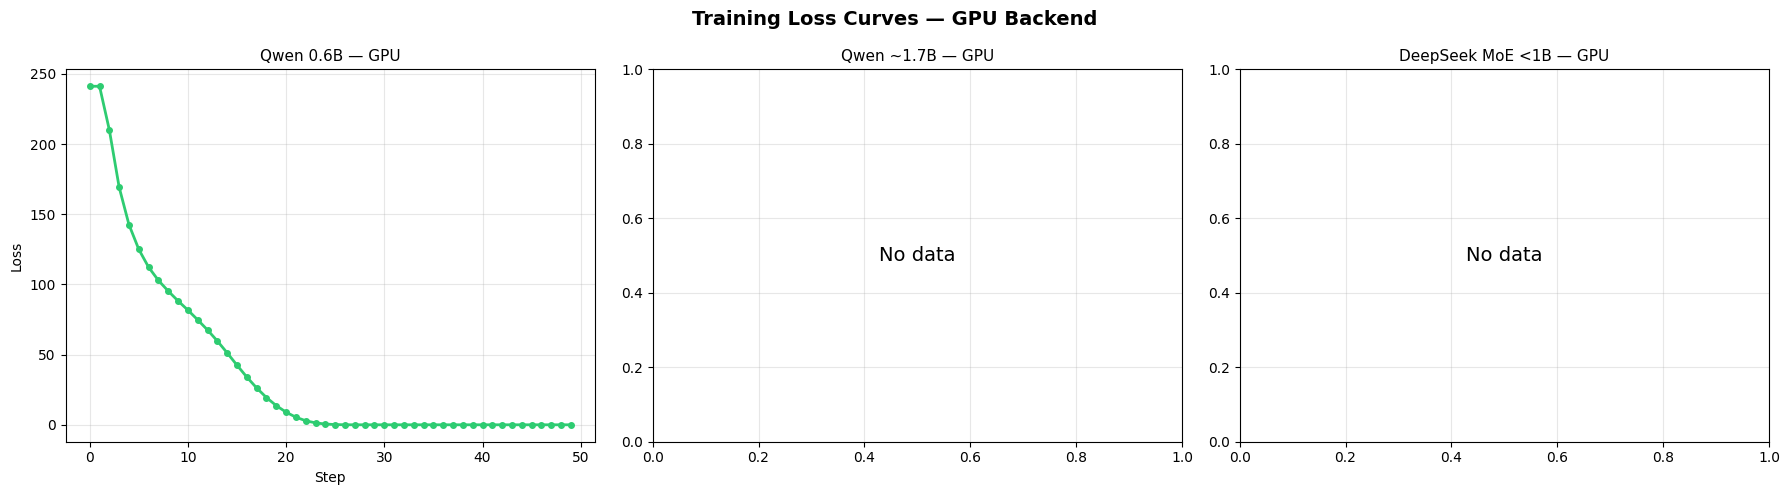

✅  Plot saved: /content/logs/gpu_loss_curves.png


In [ ]:
# Loss curves for all three models on this backend
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colours = {"cpu": "#e74c3c", "gpu": "#2ecc71", "tpu": "#3498db"}
c = colours.get(BACKEND, "#95a5a6")

for ax, (metrics, title) in zip(axes, [
    (met_qwen06b,  f"Qwen 0.6B — {BACKEND.upper()}"),
    (met_qwen17b,  f"Qwen ~1.7B — {BACKEND.upper()}"),
    (met_deepseek, f"DeepSeek MoE <1B — {BACKEND.upper()}"),
]):
    sd = metrics.get("steps", [])
    if sd:
        xs = [s["step"]  for s in sd]
        ys = [s.get("loss", float("nan")) for s in sd]
        ax.plot(xs, ys, "o-", color=c, linewidth=2, markersize=4)
        ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, fontsize=14)
    ax.set_title(title, fontsize=11); ax.grid(True, alpha=0.3)

plt.suptitle(f"Training Loss Curves — {BACKEND.upper()} Backend", fontsize=14, fontweight="bold")
plt.tight_layout()
out_path = f"{LOG_DIR}/{BACKEND}_loss_curves.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Plot saved: {out_path}")


### Export All Metrics (for cross-backend consolidation)

In [ ]:
# Export all metrics as JSON for cross-backend consolidation
payload = {
    "backend": BACKEND,
    "qwen_0.6b":  {"metrics": met_qwen06b,  "summary": sum_qwen06b},
    "qwen_1.7b":  {"metrics": met_qwen17b,  "summary": sum_qwen17b},
    "deepseek":   {"metrics": met_deepseek, "summary": sum_deepseek},
}
out_json = f"{LOG_DIR}/{BACKEND}_all_metrics.json"
with open(out_json, "w") as f:
    json.dump(payload, f, indent=2, default=str)
print(f"✅  All metrics saved: {out_json}")
print(f"\nDirectory listing:")
import glob
for p in sorted(glob.glob(f"{LOG_DIR}/**/*", recursive=True)):
    if os.path.isfile(p):
        size = os.path.getsize(p)
        print(f"   {p}  ({size} bytes)")


✅  All metrics saved: /content/logs/gpu_all_metrics.json

Directory listing:
   /content/logs/gpu_all_metrics.json  (10695 bytes)
   /content/logs/gpu_loss_curves.png  (68264 bytes)
   /content/logs/summary_gpu.csv  (206 bytes)
   /content/logs/task2/qwen_0.6b_gpu.log  (84956 bytes)
   /content/logs/task2/qwen_1.7b_gpu.log  (78253 bytes)
   /content/logs/task3/deepseek_sub1b_gpu.log  (212005 bytes)
